This tutorial is inspired by:

https://gist.github.com/lan496/ee0bd7a52df99029ac0aacbe69f2bf57

In [ ]:

%matplotlib inline
import matplotlib.pyplot as plt

In [59]:
import pymatgen.core
print(pymatgen.core.__version__)



2025.6.14


In [63]:
from pymatgen.electronic_structure.core import OrbitalType
from pymatgen.electronic_structure.plotter import DosPlotter
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.core import Element



In [ ]:
# dos.py documetation:
# https://github.com/materialsproject/pymatgen-core/blob/main/src/pymatgen/electronic_structure/dos.py

result = Vasprun('./lobster/vasprun.xml', parse_potcar_file=False)
complete_dos = result.complete_dos
pdos_Ga = complete_dos.get_element_spd_dos(Element("Ga"))
pdos_As = complete_dos.get_element_spd_dos(Element("As"))

In [65]:


plotter = DosPlotter()
plotter.add_dos('Total DOS', complete_dos)
plotter.add_dos('Ga(s)', pdos_Ga[OrbitalType.s])
plotter.add_dos('Ga(p)', pdos_Ga[OrbitalType.p])
plotter.add_dos('As(s)', pdos_As[OrbitalType.s])
plotter.add_dos('As(p)', pdos_As[OrbitalType.p])



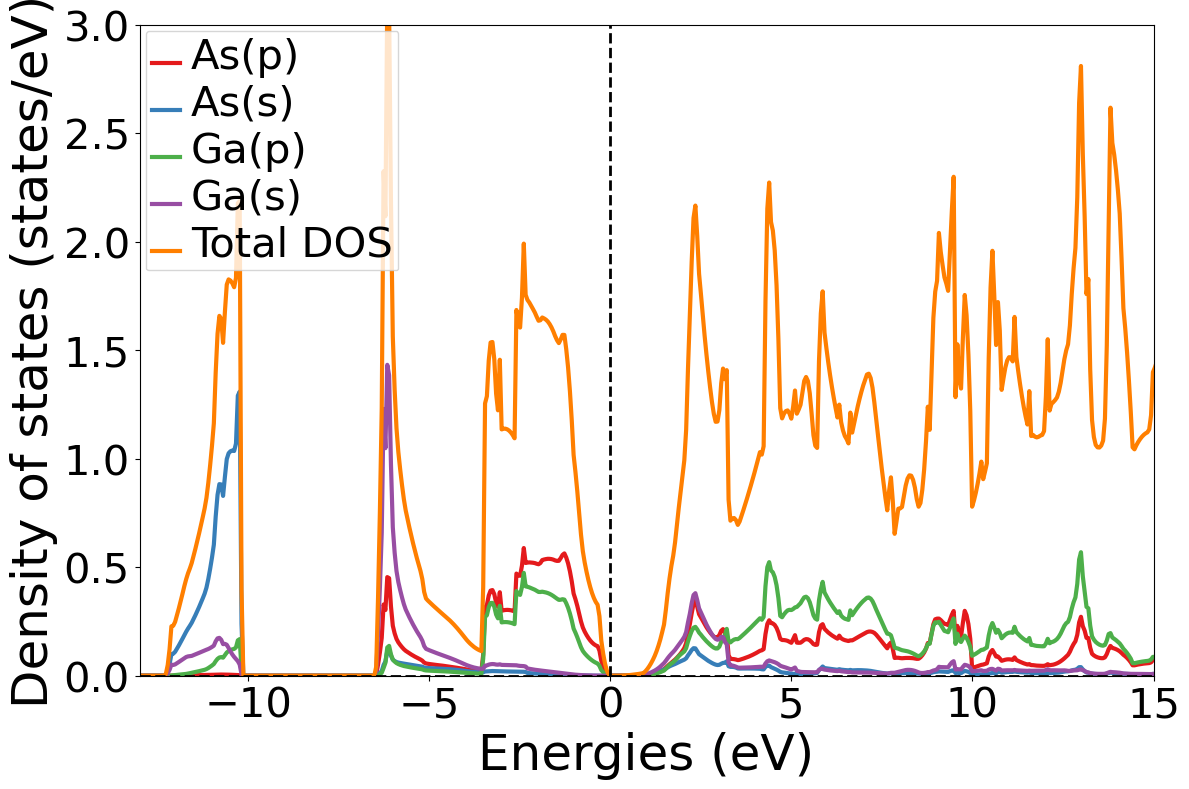

In [67]:
ax=plotter.get_plot(xlim=(-13, 15), ylim=(0, 3))
ax.figure.savefig("GaAs_dos.pdf", dpi=300)



In [68]:
from pymatgen.electronic_structure.cohp import CompleteCohp
from pymatgen.electronic_structure.plotter import CohpPlotter

In [73]:
! cat lobster/new/ICOHPLIST.lobster



  COHP#    atomMU    atomNU   distance   translation   ICOHP (at) eF 
                                                          for spin 1 
      1       Ga1       Ga1    5.76301     1  -1  -1        -0.00263 
      1    Ga1_4s    Ga1_4s    5.76301     1  -1  -1        -0.00055 
      1    Ga1_4s  Ga1_4p_y    5.76301     1  -1  -1        -0.00050 
      1    Ga1_4s  Ga1_4p_z    5.76301     1  -1  -1        -0.00025 
      1    Ga1_4s  Ga1_4p_x    5.76301     1  -1  -1        -0.00000 
      1  Ga1_4p_y    Ga1_4s    5.76301     1  -1  -1        -0.00050 
      1  Ga1_4p_y  Ga1_4p_y    5.76301     1  -1  -1        -0.00030 
      1  Ga1_4p_y  Ga1_4p_z    5.76301     1  -1  -1        -0.00016 
      1  Ga1_4p_y  Ga1_4p_x    5.76301     1  -1  -1         0.00000 
      1  Ga1_4p_z    Ga1_4s    5.76301     1  -1  -1        -0.00025 
      1  Ga1_4p_z  Ga1_4p_y    5.76301     1  -1  -1        -0.00016 
      1  Ga1_4p_z  Ga1_4p_z    5.76301     1  -1  -1        -0.00003 
      1  Ga1_4p_z  G

In [75]:
complete_cohp = CompleteCohp.from_file(fmt='LOBSTER', filename='lobster/new/COHPCAR.lobster', structure_file='lobster/new/POSCAR')

In [76]:


# all labels are symmetrically equivalent 
label = "23"

cohp = complete_cohp.get_cohp_by_label(label)
cohp_Ga4s_As4s = complete_cohp.get_orbital_resolved_cohp(label, "4s-4s")
cohp_Ga4s_As4px = complete_cohp.get_orbital_resolved_cohp(label, "4s-4px")
cohp_Ga4px_As4px = complete_cohp.get_orbital_resolved_cohp(label, "4px-4px")
cohp_Ga4px_As4py = complete_cohp.get_orbital_resolved_cohp(label, "4px-4py")



In [78]:
cohp_plotter = CohpPlotter()
cohp_plotter.add_cohp("Ga-As", cohp)
cohp_plotter.add_cohp("Ga(4s)-As(4s)", cohp_Ga4s_As4s)
cohp_plotter.add_cohp("Ga(4s)-As(4px)", cohp_Ga4s_As4px)
cohp_plotter.add_cohp("Ga(4px)-As(4px)", cohp_Ga4px_As4px)
cohp_plotter.add_cohp("Ga(4px)-As(4py)", cohp_Ga4px_As4py)



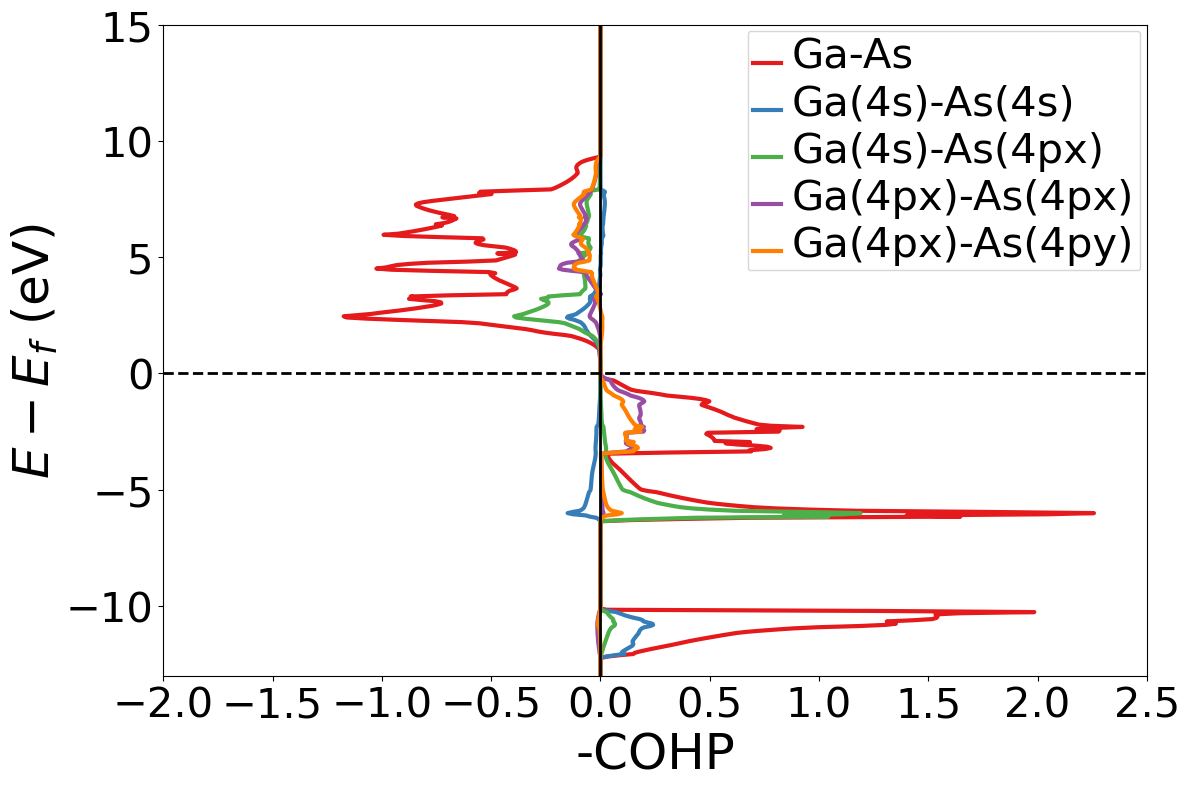

In [79]:
ax=cohp_plotter.get_plot(xlim=(-2, 2.5), ylim=(-13, 15))
ax.figure.savefig('GaAs_cohp.pdf', dpi=500)

